### COMP3055 Machine Learning Coursework

### Import packages and configuration

#### Packages

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

#### Configuration

In [33]:
train_sub = 5000 
seed = 42
pca_feature_dir = "./pca_features" 
os.makedirs(pca_feature_dir, exist_ok=True)
fig_dir= "./figs"
os.makedirs(fig_dir, exist_ok=True)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

CIFAR10_CLASSES = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]
ratios= [0.10, 0.30, 0.50, 0.70, 0.80, 0.90, None]
tags = ["0.10", "0.30", "0.50", "0.70", "0.80", "0.90", "1.00"]

Using device: cuda


### Task 1: PCA Feature Extraction on CIFAR-10

#### Functions

In [34]:
def load_cifar10():
    """
    Load CIFAR-10 training and testing datasets and return DataLoaders.
    """    
    transform = transforms.ToTensor()
    train_set = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )
    test_set = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )
    train_loader = DataLoader(train_set, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=512, shuffle=False)

    return train_loader, test_loader

def dataset_to_numpy(dataloader):
    """
    Convert images and labels from a PyTorch DataLoader into NumPy arrays.
    """
    X_list, y_list = [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.cpu()
            labels = labels.cpu()

            imgs = imgs.reshape(imgs.size(0), -1)

            X_list.append(imgs.numpy())
            y_list.append(labels.numpy())

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    return X, y

def subsample_train_set(X, y, n_samples=5000, seed=42):
    """
    Randomly subsample the training set without replacement.
    """
    np.random.seed(seed)

    idx = np.random.choice(len(y), size=n_samples, replace=False)
    X_sub = X[idx]
    y_sub = y[idx]
    print(f"Subsampled train set to {X_sub.shape}")
    return X_sub, y_sub


def run_pca_and_save(X_train, y_train, X_test, y_test,ratios):
    """
    Apply PCA with different variance-retention ratios and save results.
    """

    np.save(os.path.join(pca_feature_dir, "y_train.npy"), y_train)
    np.save(os.path.join(pca_feature_dir, "y_test.npy"), y_test)

    for ratio in ratios:
        if ratio is None:
            pca = PCA(n_components=None, svd_solver="full", random_state=42)
            tag = "1.00"  
        else:
            pca = PCA(n_components=ratio, svd_solver="full", random_state=42)
            tag = f"{ratio:.2f}"
        
        Z_train = pca.fit_transform(X_train)
        Z_test = pca.transform(X_test)
        np.save(os.path.join(pca_feature_dir, f"train_{tag}.npy"), Z_train)
        np.save(os.path.join(pca_feature_dir, f"test_{tag}.npy"), Z_test)

        print(f"PCA {tag}: train {Z_train.shape}, test {Z_test.shape}")


#### Results

In [35]:
# model training 
train_loader, test_loader = load_cifar10()
X_train_full, y_train_full = dataset_to_numpy(train_loader)
X_test, y_test = dataset_to_numpy(test_loader)
X_train, y_train = subsample_train_set(
    X_train_full, y_train_full,
    n_samples=train_sub,
    seed=seed
)
run_pca_and_save(X_train, y_train, X_test, y_test,ratios)

Files already downloaded and verified
Files already downloaded and verified
Subsampled train set to (5000, 3072)
PCA 0.10: train (5000, 1), test (10000, 1)
PCA 0.30: train (5000, 2), test (10000, 2)
PCA 0.50: train (5000, 4), test (10000, 4)
PCA 0.70: train (5000, 14), test (10000, 14)
PCA 0.80: train (5000, 32), test (10000, 32)
PCA 0.90: train (5000, 95), test (10000, 95)
PCA 1.00: train (5000, 3072), test (10000, 3072)


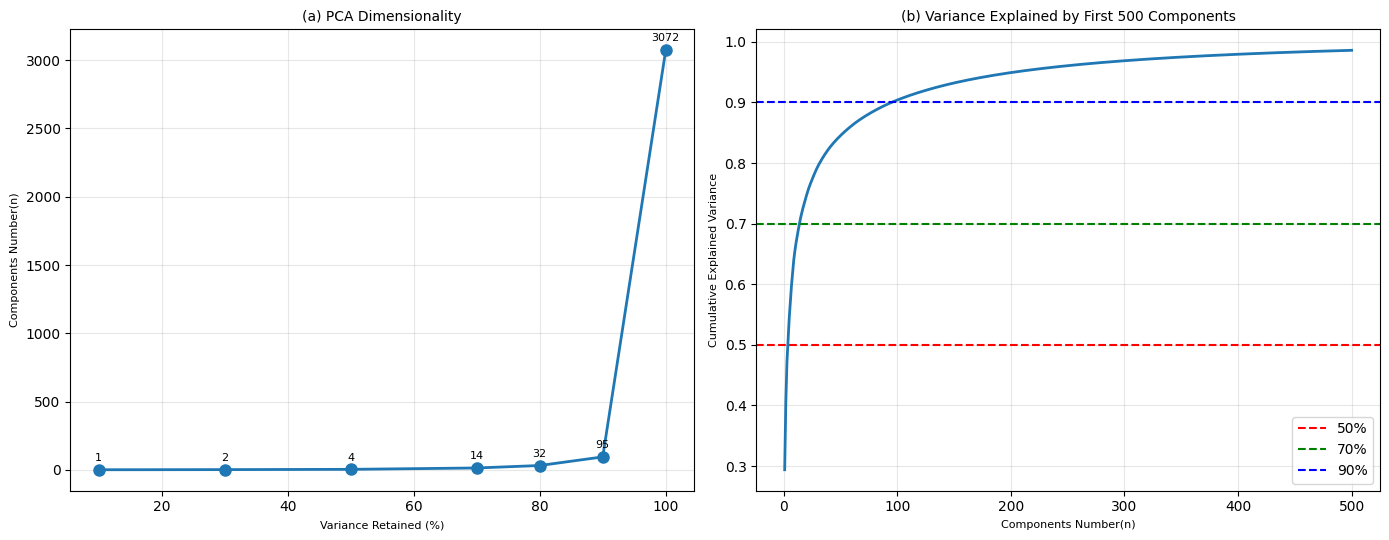

In [36]:
# result visualiztion 
variance_levels = []
n_components = []
ratios = [0.10, 0.30, 0.50, 0.70, 0.80, 0.90, 1.0]
for ratio in ratios:
    train_data = np.load(os.path.join(pca_feature_dir, f"train_{ratio:.2f}.npy"))
    variance_levels.append(int(ratio * 100))
    n_components.append(train_data.shape[1])
    
pca_full=PCA(n_components=None, random_state=42)
pca_full.fit(X_train)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) 
n_component_range = np.arange(1, len(cumulative_variance) + 1)

plt.figure(figsize=(14, 5.5))  
plt.subplot(1, 2, 1)
plt.plot(variance_levels, n_components, marker='o', linewidth=2, markersize=8)
for i, (x, y) in enumerate(zip(variance_levels, n_components)):
    plt.text(x, y + 50, f'{y}', ha='center', va='bottom', fontsize=8) 
plt.xlabel('Variance Retained (%)', fontsize=8)
plt.ylabel('Components Number(n)', fontsize=8)
plt.grid(True, alpha=0.3)
plt.title('(a) PCA Dimensionality', fontsize=10)
plt.subplot(1, 2, 2)
plt.plot(n_component_range[:500], cumulative_variance[:500], linewidth=2)
plt.axhline(y=0.50, color='r', linestyle='--', label='50%')
plt.axhline(y=0.70, color='g', linestyle='--', label='70%')
plt.axhline(y=0.90, color='b', linestyle='--', label='90%')
plt.xlabel('Components Number(n)', fontsize=8)
plt.ylabel('Cumulative Explained Variance', fontsize=8)
plt.title('(b) Variance Explained by First 500 Components', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'task1.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### Task 2: MLP Classification using PCA Features

#### function

In [37]:
def load_pca_feature(ratio: str, split: str):
    """
    Load PCA-reduced features generated in Task 1.
    """
    X = np.load(os.path.join(pca_feature_dir, f"{split}_{ratio}.npy"))
    y = np.load(os.path.join(pca_feature_dir, f"y_{split}.npy"))
    print(f"PCA {ratio} : {split} {X.shape}")
    return X.astype(np.float32), y.astype(np.int64)

class MLP(nn.Module):
    """
    The MLP consists of two hidden layers with batch normalization and dropout.
    """
    def __init__(self, input_dim, hidden_dim=256, output_dim=10, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.fc3(x)

def init_weights(m):
    """
    Initialize MLP weights
    """
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

def cross_validate(X, y, input_dim, hidden_dim, lr, n_epochs, batch=128, seed=42):
    """
    We evaluate the MLP using stratified 5-fold cross-validation and report mean accuracy and weighted F1 score.
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    train_accs = []
    test_accs  = []
    train_f1s  = []
    test_f1s   = []
    fold_times = []  

    for tr, va in skf.split(X, y):
        fold_start = time.time()

        model = MLP(input_dim, hidden_dim).to(device)
        model.apply(init_weights)

        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        loss_fn = nn.CrossEntropyLoss()

        Xtr = torch.tensor(X[tr]).to(device)
        ytr = torch.tensor(y[tr]).to(device)
        Xva = torch.tensor(X[va]).to(device)
        yva = torch.tensor(y[va]).to(device)

        loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch, shuffle=True)

        for _ in range(n_epochs):
            model.train()
            for xb, yb in loader:
                opt.zero_grad()
                loss_fn(model(xb), yb).backward()
                opt.step()

        fold_time = (time.time() - fold_start) / 60
        fold_times.append(fold_time)
        model.eval()
        with torch.no_grad():
            train_pred = model(Xtr).argmax(dim=1)
            test_pred  = model(Xva).argmax(dim=1)

        train_accs.append(accuracy_score(ytr.cpu(), train_pred.cpu()))
        test_accs.append(accuracy_score(yva.cpu(), test_pred.cpu()))
        train_f1s.append(f1_score(ytr.cpu(), train_pred.cpu(), average="macro"))
        test_f1s.append(f1_score(yva.cpu(), test_pred.cpu(), average="macro"))

    total_time_min = np.sum(fold_times)

    return (
        np.mean(train_accs),
        np.mean(test_accs),
        np.mean(train_f1s),
        np.mean(test_f1s),
        fold_times,
        total_time_min
    )

def train_and_test(Xtr, ytr, Xte, yte, input_dim, hidden_dim, lr, n_epochs=30):
    """
    Train MLP and return both final results AND epoch-by-epoch history.
    """
    model = MLP(input_dim, hidden_dim).to(device)
    model.apply(init_weights)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    
    Xtr_tensor = torch.tensor(Xtr).to(device)
    ytr_tensor = torch.tensor(ytr).to(device)
    Xte_tensor = torch.tensor(Xte).to(device)
    yte_tensor = torch.tensor(yte).to(device)
    
    loader = DataLoader(TensorDataset(Xtr_tensor, ytr_tensor), batch_size=128, shuffle=True)

    train_loss_hist = []
    train_acc_hist = []
    test_loss_hist = []
    test_acc_hist = []
    
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0
        correct = 0
        
        for xb, yb in loader:
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
            
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
        
        train_loss = running_loss / len(Xtr_tensor)
        train_acc = correct / len(Xtr_tensor)
        
        model.eval()
        with torch.no_grad():
            test_out = model(Xte_tensor)
            test_loss = loss_fn(test_out, yte_tensor).item()
            test_pred = test_out.argmax(1)
            test_acc = accuracy_score(yte_tensor.cpu(), test_pred.cpu())
        
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)
    
    model.eval()
    with torch.no_grad():
        train_pred = model(Xtr_tensor).argmax(dim=1)
        test_pred = model(Xte_tensor).argmax(dim=1)
    
    per_class_acc = []
    for class_idx in range(10):
        class_mask = (yte_tensor.cpu() == class_idx)
        if class_mask.sum() > 0:
            class_correct = (test_pred.cpu()[class_mask] == class_idx).sum().item()
            class_acc = class_correct / class_mask.sum().item()
            per_class_acc.append(class_acc)
        else:
            per_class_acc.append(0.0)
    
    return {
        "train_acc": train_acc_hist[-1],
        "test_acc": test_acc_hist[-1],
        "train_macro_f1": f1_score(ytr_tensor.cpu(), train_pred.cpu(), average="macro"),
        "test_macro_f1": f1_score(yte_tensor.cpu(), test_pred.cpu(), average="macro"),
        "per_class_f1": f1_score(yte_tensor.cpu(), test_pred.cpu(), average=None),
        "per_class_acc": per_class_acc,
        "train_loss_hist": train_loss_hist,
        "train_acc_hist": train_acc_hist,
        "test_loss_hist": test_loss_hist,
        "test_acc_hist": test_acc_hist
    }

#### Task 2.1: Do 5-fold cross validation with different input feature vectors

In [ ]:
baseline_hidden = 256
baseline_lr = 3e-3
cv_plot_rows = []
feature_configs = [
    (f"PCA{v}%", tag)
    for tag, v in zip(tags, variance_levels)
]
for name, tag in feature_configs:
    Xtr, ytr = load_pca_feature(tag, "train")
    tr_acc, te_acc, tr_f1, te_f1, fold_times, total_time_min = cross_validate(
        Xtr, ytr,
        n_epochs=30,
        input_dim=Xtr.shape[1],
        hidden_dim=baseline_hidden,
        lr=baseline_lr
    )
    
    cv_plot_rows.append({
        "Feature": name,
        "Train_Acc": tr_acc,
        "Val_Acc":  te_acc,
        "Train_F1":  tr_f1,
        "Val_F1":   te_f1,
        "Fold_Times": fold_times,
        "Time_min": total_time_min
    })
df_cv_plot = pd.DataFrame(cv_plot_rows)
display(df_cv_plot)

PCA 0.10 : train (5000, 1)
PCA 0.30 : train (5000, 2)
PCA 0.50 : train (5000, 4)
PCA 0.70 : train (5000, 14)
PCA 0.80 : train (5000, 32)
PCA 0.90 : train (5000, 95)
PCA 1.00 : train (5000, 3072)


,Feature,Train_Acc,Val_Acc,Train_F1,Val_F1,Fold_Times,Time_min
0,PCA10%,0.16325,0.1520,0.114885,0.107515,"[0.029154396057128905, 0.029079079627990723, 0...",0.144861
1,PCA30%,0.21715,0.2012,0.195503,0.180938,"[0.028742305437723794, 0.028170661131540934, 0...",0.141925
2,PCA50%,0.29375,0.2624,0.284100,0.253286,"[0.02820799748102824, 0.02855813503265381, 0.0...",0.142516
3,PCA70%,0.48590,0.3846,0.482600,0.381377,"[0.028420750300089517, 0.02773102919260661, 0....",0.139047
4,PCA80%,0.63895,0.4340,0.636477,0.430842,"[0.027720332145690918, 0.02814141909281413, 0....",0.142082
5,PCA90%,0.84605,0.4566,0.845930,0.454861,"[0.029020527998606365, 0.02831002076466878, 0....",0.141831
6,PCA100%,0.99990,0.3692,0.999898,0.368588,"[0.030242053667704265, 0.029202655951182047, 0...",0.148615


#### Task 2.3: Hyper-parameter Tuning (100% PCA)

In [ ]:
# Use full PCA features (100% variance = original 3072 dims)
ratio = "1.00"
Xtr, ytr = load_pca_feature(ratio, "train")
Xte, yte = load_pca_feature(ratio, "test")

# Hyper-parameter configurations to compare
hyper_grid = [
    ("h256_lr3e-3", 256, 3e-3),
    ("h512_lr3e-3", 512, 3e-3),
    ("h512_lr1e-3", 512, 1e-3),
]
learning_curves = []
final_results = []
per_class_rows_24 = []

# Train and evaluate each MLP configuration
for name, hidden_dim, lr in hyper_grid:
    model = MLP(Xtr.shape[1], hidden_dim).to(device)
    model.apply(init_weights)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    
    Xtr_tensor = torch.tensor(Xtr).to(device)
    ytr_tensor = torch.tensor(ytr).to(device)
    Xte_tensor = torch.tensor(Xte).to(device)
    yte_tensor = torch.tensor(yte).to(device)
    
    loader = DataLoader(TensorDataset(Xtr_tensor, ytr_tensor), batch_size=128, shuffle=True)
    
    train_acc_history = []
    test_acc_history = []
    train_f1_history = []
    test_f1_history = []
    
    n_epochs = 30
    
     # Training loop
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        
        model.eval()
        with torch.no_grad():
            train_pred = model(Xtr_tensor).argmax(dim=1)
            test_pred = model(Xte_tensor).argmax(dim=1)
        
        train_acc = accuracy_score(ytr_tensor.cpu(), train_pred.cpu())
        test_acc = accuracy_score(yte_tensor.cpu(), test_pred.cpu())
        train_f1 = f1_score(ytr_tensor.cpu(), train_pred.cpu(), average='macro')
        test_f1 = f1_score(yte_tensor.cpu(), test_pred.cpu(), average='macro')
        
        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)
        train_f1_history.append(train_f1)
        test_f1_history.append(test_f1)
    
    # Save learning curves for plotting
    learning_curves.append({
        'name': name,
        'train_acc': train_acc_history,
        'test_acc': test_acc_history,
        'train_f1': train_f1_history,
        'test_f1': test_f1_history
    })
    
    per_class_f1 = f1_score(yte_tensor.cpu(), test_pred.cpu(), average=None)
    per_class_acc = []
    for class_idx in range(10):
        class_mask = (yte_tensor.cpu() == class_idx)
        if class_mask.sum() > 0:
            class_correct = (test_pred.cpu()[class_mask] == class_idx).sum().item()
            class_acc = class_correct / class_mask.sum().item()
            per_class_acc.append(class_acc)
        else:
            per_class_acc.append(0.0)
    
    final_results.append({
        'name': name,
        'train_acc': train_acc_history[-1],
        'test_acc': test_acc_history[-1],
        'train_f1': train_f1_history[-1],
        'test_f1': test_f1_history[-1]
    })
    
    # Store per-class results for later visualisation
    for i, cname in enumerate(CIFAR10_CLASSES):
        per_class_rows_24.append({
            'Config': name,
            'Class': cname,
            'F1': per_class_f1[i],
            'Accuracy': per_class_acc[i]
        })



PCA 1.00 : train (5000, 3072)
PCA 1.00 : test (10000, 3072)


#### Task 2.2, 2.4: Results and Visualization

##### Data

In [40]:
# 2.2
rows_22 = []
per_class_rows_22 = []
for tag, v in zip(tags, variance_levels):
    Xtr_pca, ytr_pca = load_pca_feature(tag, "train")
    Xte_pca, yte_pca = load_pca_feature(tag, "test")
    res = train_and_test(
        Xtr_pca, ytr_pca, Xte_pca, yte_pca,
        input_dim=Xtr_pca.shape[1],
        hidden_dim=baseline_hidden,
        lr=baseline_lr
    )
    rows_22.append({
        "Var(%)": v,
        "Dim": Xtr_pca.shape[1],
        "Train_Acc": res["train_acc"],
        "Test_Acc": res["test_acc"],
        "Train_MacroF1": res["train_macro_f1"],
        "Test_MacroF1": res["test_macro_f1"],
    })
    for i, cname in enumerate(CIFAR10_CLASSES):
        per_class_rows_22.append({
            "Var(%)": v,
            "Dim": Xtr_pca.shape[1],
            "Class": cname,
            "F1": res["per_class_f1"][i],
            "Accuracy": res["per_class_acc"][i]
        })

df_pca_22 = pd.DataFrame(rows_22)
df_per_class_22 = pd.DataFrame(per_class_rows_22)
# 2.4
df_per_class_24 = pd.DataFrame(per_class_rows_24)
df_final_24 = pd.DataFrame(final_results)

PCA 0.10 : train (5000, 1)
PCA 0.10 : test (10000, 1)
PCA 0.30 : train (5000, 2)
PCA 0.30 : test (10000, 2)
PCA 0.50 : train (5000, 4)
PCA 0.50 : test (10000, 4)
PCA 0.70 : train (5000, 14)
PCA 0.70 : test (10000, 14)
PCA 0.80 : train (5000, 32)
PCA 0.80 : test (10000, 32)
PCA 0.90 : train (5000, 95)
PCA 0.90 : test (10000, 95)
PCA 1.00 : train (5000, 3072)
PCA 1.00 : test (10000, 3072)


##### visualization

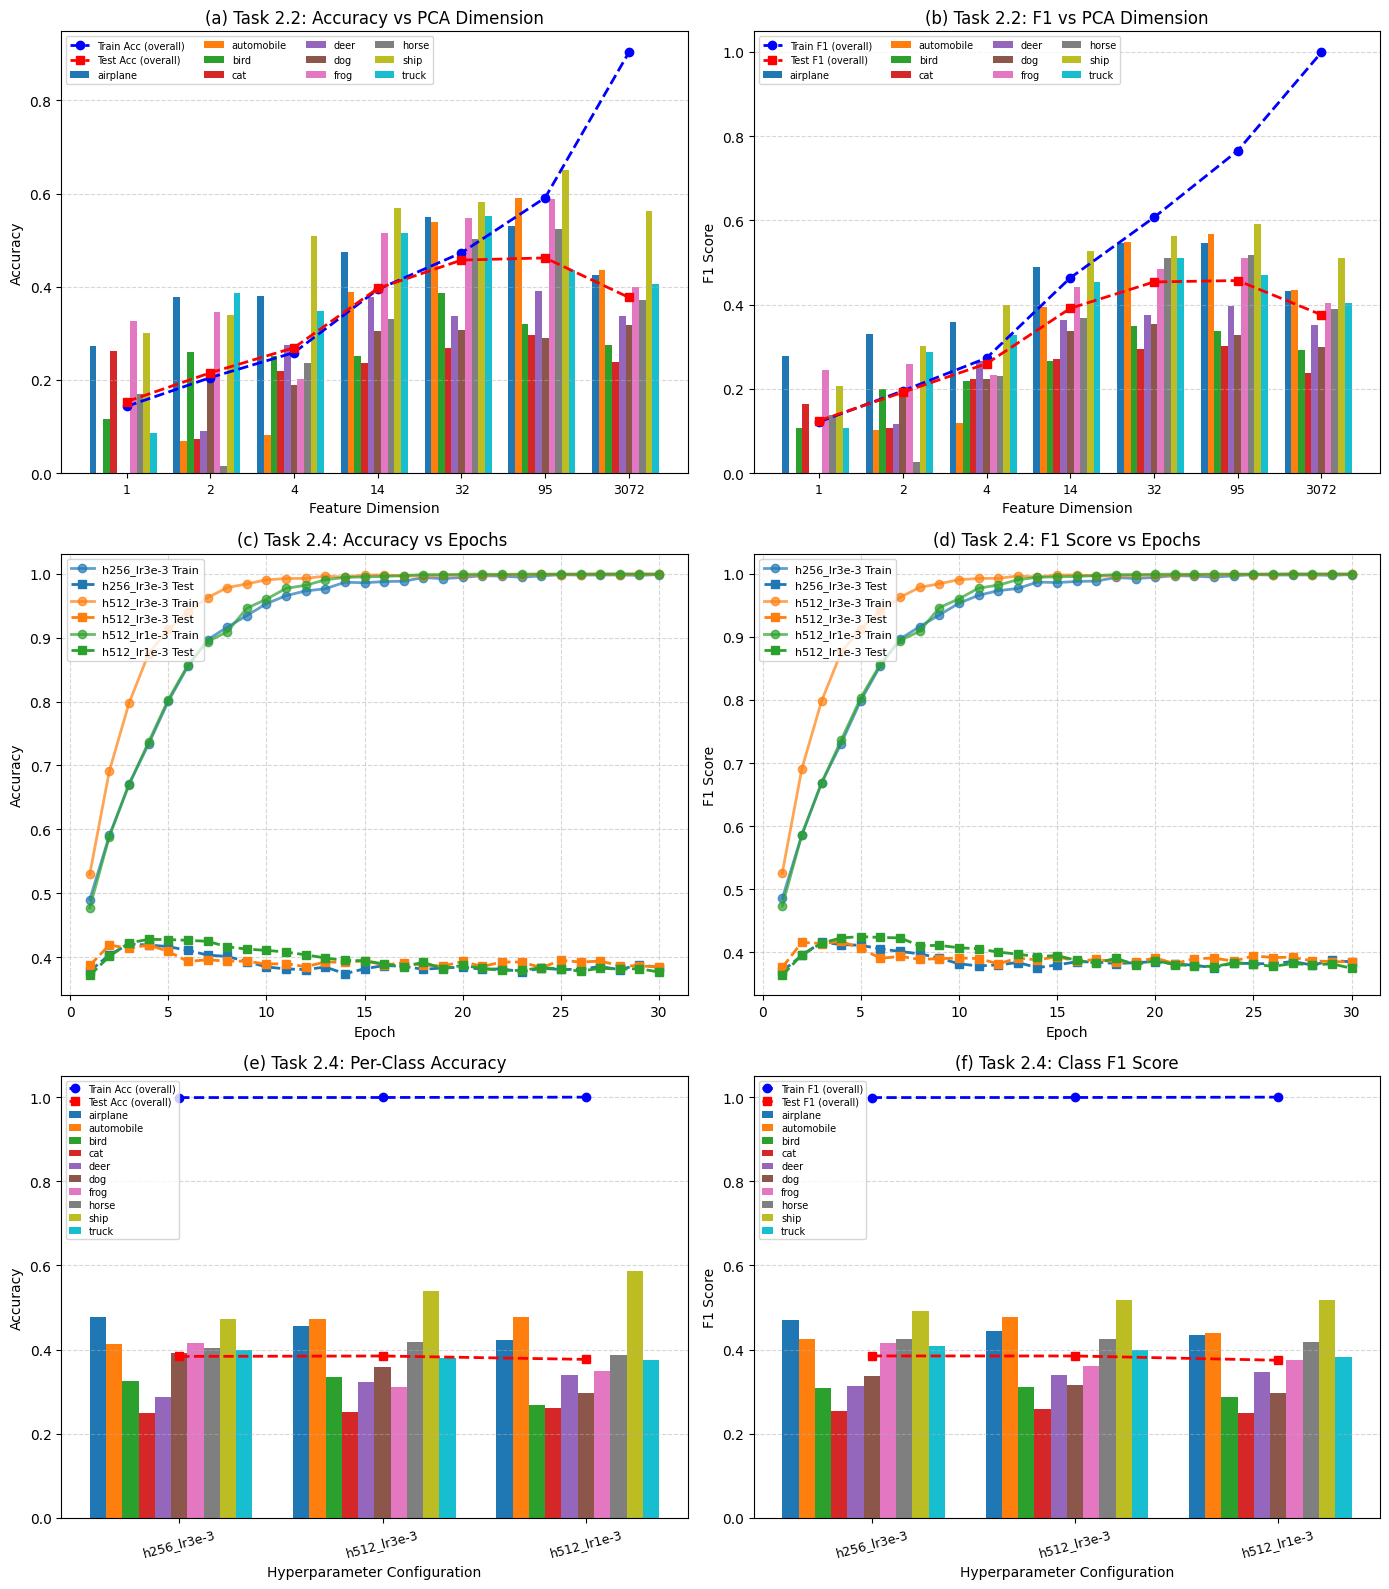

In [49]:
fig = plt.figure(figsize=(14, 16))
colors = ['tab:blue', 'tab:orange', 'tab:green']
ax1 = plt.subplot(3, 2, 1)
dims_22 = sorted(df_pca_22["Dim"].unique())
x_22 = np.arange(len(dims_22))
bar_w = 0.08

for idx, cname in enumerate(CIFAR10_CLASSES):
    df_tmp = df_per_class_22[df_per_class_22["Class"] == cname].copy()
    df_tmp = df_tmp.sort_values("Dim")
    ax1.bar(x_22 + idx * bar_w, df_tmp["Accuracy"].values, width=bar_w, label=cname)

df_sorted_22 = df_pca_22.sort_values("Dim")
ax1.plot(x_22 + bar_w * (len(CIFAR10_CLASSES) / 2), df_sorted_22["Train_Acc"].values,
         linestyle="--", linewidth=2, marker='o', color="blue", label="Train Acc (overall)")
ax1.plot(x_22 + bar_w * (len(CIFAR10_CLASSES) / 2), df_sorted_22["Test_Acc"].values,
         linestyle="--", linewidth=2, marker='s', color="red", label="Test Acc (overall)")

ax1.set_xticks(x_22 + bar_w * (len(CIFAR10_CLASSES) / 2))
ax1.set_xticklabels(dims_22, fontsize=9)
ax1.set_xlabel("Feature Dimension")
ax1.set_ylabel("Accuracy")
ax1.set_title("(a) Task 2.2: Accuracy vs PCA Dimension")
ax1.legend(ncol=4, fontsize=7)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

ax2 = plt.subplot(3, 2, 2)

for idx, cname in enumerate(CIFAR10_CLASSES):
    df_tmp = df_per_class_22[df_per_class_22["Class"] == cname].copy()
    df_tmp = df_tmp.sort_values("Dim")
    ax2.bar(x_22 + idx * bar_w, df_tmp["F1"].values, width=bar_w, label=cname)

ax2.plot(x_22 + bar_w * (len(CIFAR10_CLASSES) / 2), df_sorted_22["Train_MacroF1"].values,
         linestyle="--", linewidth=2, marker='o', color="blue", label="Train F1 (overall)")
ax2.plot(x_22 + bar_w * (len(CIFAR10_CLASSES) / 2), df_sorted_22["Test_MacroF1"].values,
         linestyle="--", linewidth=2, marker='s', color="red", label="Test F1 (overall)")

ax2.set_xticks(x_22 + bar_w * (len(CIFAR10_CLASSES) / 2))
ax2.set_xticklabels(dims_22, fontsize=9)
ax2.set_xlabel("Feature Dimension")
ax2.set_ylabel("F1 Score")
ax2.set_title("(b) Task 2.2: F1 vs PCA Dimension")
ax2.legend(ncol=4, fontsize=7)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

epochs = range(1, n_epochs + 1)
ax3 = plt.subplot(3, 2, 3)
for idx, curve in enumerate(learning_curves):
    ax3.plot(epochs, curve['train_acc'], linestyle='-', linewidth=2, marker='o',
             color=colors[idx], label=f"{curve['name']} Train", alpha=0.7)
    ax3.plot(epochs, curve['test_acc'], linestyle='--', linewidth=2, marker='s',
             color=colors[idx], label=f"{curve['name']} Test")

ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.set_title('(c) Task 2.4: Accuracy vs Epochs ')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, linestyle='--', alpha=0.5)

ax4 = plt.subplot(3, 2, 4)
for idx, curve in enumerate(learning_curves):
    ax4.plot(epochs, curve['train_f1'], linestyle='-', linewidth=2, marker='o',
             color=colors[idx], label=f"{curve['name']} Train", alpha=0.7)
    ax4.plot(epochs, curve['test_f1'], linestyle='--', linewidth=2, marker='s',
             color=colors[idx], label=f"{curve['name']} Test")

ax4.set_xlabel('Epoch')
ax4.set_ylabel('F1 Score')
ax4.set_title('(d) Task 2.4: F1 Score vs Epochs')
ax4.legend(loc='upper left', fontsize=8)
ax4.grid(True, linestyle='--', alpha=0.5)
ax5 = plt.subplot(3, 2, 5)
configs = df_final_24['name'].tolist()
x_24 = np.arange(len(configs))

for idx, cname in enumerate(CIFAR10_CLASSES):
    df_tmp = df_per_class_24[df_per_class_24['Class'] == cname].copy()
    ax5.bar(x_24 + idx * bar_w, df_tmp['Accuracy'].values, width=bar_w, label=cname)

ax5.plot(x_24 + bar_w * (len(CIFAR10_CLASSES) / 2), df_final_24['train_acc'].values,
         linestyle='--', linewidth=2, marker='o', color='blue', label='Train Acc (overall)')
ax5.plot(x_24 + bar_w * (len(CIFAR10_CLASSES) / 2), df_final_24['test_acc'].values,
         linestyle='--', linewidth=2, marker='s', color='red', label='Test Acc (overall)')

ax5.set_xticks(x_24 + bar_w * (len(CIFAR10_CLASSES) / 2))
ax5.set_xticklabels(configs, rotation=15, fontsize=9)
ax5.set_xlabel('Hyperparameter Configuration')
ax5.set_ylabel('Accuracy')
ax5.set_title('(e) Task 2.4: Per-Class Accuracy')
ax5.grid(axis='y', linestyle='--', alpha=0.5)
ax5.legend(
    loc='upper left',
    fontsize=7,      
    frameon=True,
    handlelength=1.2,  
    borderpad=0.3,    
    labelspacing=0.3   
)

ax6 = plt.subplot(3, 2, 6)
for idx, cname in enumerate(CIFAR10_CLASSES):
    df_tmp = df_per_class_24[df_per_class_24['Class'] == cname].copy()
    ax6.bar(x_24 + idx * bar_w, df_tmp['F1'].values, width=bar_w, label=cname)
ax6.plot(x_24 + bar_w * (len(CIFAR10_CLASSES) / 2), df_final_24['train_f1'].values,
         linestyle='--', linewidth=2, marker='o', color='blue', label='Train F1 (overall)')
ax6.plot(x_24 + bar_w * (len(CIFAR10_CLASSES) / 2), df_final_24['test_f1'].values,
         linestyle='--', linewidth=2, marker='s', color='red', label='Test F1 (overall)')

ax6.set_xticks(x_24 + bar_w * (len(CIFAR10_CLASSES) / 2))
ax6.set_xticklabels(configs, rotation=15, fontsize=9)
ax6.set_xlabel('Hyperparameter Configuration')
ax6.set_ylabel('F1 Score')
ax6.set_title('(f) Task 2.4: Class F1 Score')
ax6.grid(axis='y', linestyle='--', alpha=0.5)
ax6.legend(
    loc='upper left',
    fontsize=7,      
    frameon=True,
    handlelength=1.2,  
    borderpad=0.3,    
    labelspacing=0.3   
)


plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "task2.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### Task 3 Better CNN

#### Functions

In [ ]:
class BetterCNN(nn.Module):
    """
    Better CNN 
    """
    def __init__(self, num_classes, dropout, channels):
        super(BetterCNN, self).__init__()
        
        self.conv1a = nn.Conv2d(3, channels[0], 3, padding=1)
        self.bn1a = nn.BatchNorm2d(channels[0])
        self.conv1b = nn.Conv2d(channels[0], channels[0], 3, padding=1)
        self.bn1b = nn.BatchNorm2d(channels[0])

        self.conv2a = nn.Conv2d(channels[0], channels[1], 3, padding=1)
        self.bn2a = nn.BatchNorm2d(channels[1])
        self.conv2b = nn.Conv2d(channels[1], channels[1], 3, padding=1)
        self.bn2b = nn.BatchNorm2d(channels[1])
        
        self.conv3a = nn.Conv2d(channels[1], channels[2], 3, padding=1)
        self.bn3a = nn.BatchNorm2d(channels[2])
        self.conv3b = nn.Conv2d(channels[2], channels[2], 3, padding=1)
        self.bn3b = nn.BatchNorm2d(channels[2])

        self.fc1 = nn.Linear(channels[2] * 4 * 4, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, num_classes)
        

    def forward(self, x):
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn3a(self.conv3a(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x
    
def five_fold_cv(epochs, samples, model_name, learning_rate, w_decay, dropout, channels):
    """
    5 fold cross-validation 
    """
    start_time = time.time()

    # Data augmentation for training
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    train_set = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )
    torch.manual_seed(42)
    indices = torch.randperm(len(train_set))[:samples].tolist()
    train_set = Subset(train_set, indices)
    labels = np.array([train_set.dataset.targets[i] for i in train_set.indices])
 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_accs = []
    fold_f1s = []
    train_fold_accs = []
    train_fold_f1s = []
    per_class_f1_list = []
    per_class_acc_list = []
    fold_times = [] 

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.arange(len(labels)), labels), 1):
        fold_start = time.time()
        print(f"\nFold {fold}")
        fold_train_indices = [train_set.indices[i] for i in train_idx]
        fold_val_indices = [train_set.indices[i] for i in val_idx]
        
        fold_train_set = Subset(train_set.dataset, fold_train_indices)
        fold_val_set = Subset(train_set.dataset, fold_val_indices)
        fold_train_loader = DataLoader(
            fold_train_set, batch_size=128, shuffle=True, num_workers=0, pin_memory=False
        )
        fold_val_loader = DataLoader(
            fold_val_set, batch_size=128, shuffle=False, num_workers=0, pin_memory=False
        )

        model = model_name(num_classes=10, dropout=dropout, channels=channels).to(device)
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=learning_rate, weight_decay=w_decay
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=1e-6
        )
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        best_val_acc = 0
        
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            train_correct = 0
            train_total = 0
            
            for X, y in fold_train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                outputs = model(X)
                loss = criterion(outputs, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
                train_loss += loss.item()
                train_correct += (outputs.argmax(1) == y).sum().item()
                train_total += y.size(0)
            
            train_acc = train_correct / train_total
            scheduler.step()
            
            if (epoch + 1) % 5 == 0:
                model.eval()
                val_correct = 0
                val_total = 0
                
                with torch.no_grad():
                    for X, y in fold_val_loader:
                        X = X.to(device)
                        outputs = model(X)
                        val_correct += (outputs.argmax(1) == y.to(device)).sum().item()
                        val_total += y.size(0)
                
                val_acc = val_correct / val_total
                if val_acc > best_val_acc:
                    best_val_acc = val_acc

        model.eval()
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for X, y in fold_val_loader:
                preds = model(X.to(device)).argmax(1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(y.numpy())
        
        acc = accuracy_score(val_labels, val_preds)
        f1 = f1_score(val_labels, val_preds, average='macro')
        per_class_f1 = f1_score(val_labels, val_preds, average=None)
        per_class_acc = []
        for class_idx in range(10):
            class_mask = np.array(val_labels) == class_idx
            if class_mask.sum() > 0:
                class_correct = (np.array(val_preds)[class_mask] == class_idx).sum()
                class_acc = class_correct / class_mask.sum()
                per_class_acc.append(class_acc)
            else:
                per_class_acc.append(0.0)
        
        fold_accs.append(acc)
        fold_f1s.append(f1)
        per_class_f1_list.append(per_class_f1)
        per_class_acc_list.append(per_class_acc)

        train_preds = []
        train_labels = []
        with torch.no_grad():
            for X, y in fold_train_loader:
                preds = model(X.to(device)).argmax(1).cpu().numpy()
                train_preds.extend(preds)
                train_labels.extend(y.numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average="macro")
        train_fold_accs.append(train_acc)
        train_fold_f1s.append(train_f1)

        fold_time = (time.time() - fold_start) / 60
        print(f"acc: {acc:.4f}; F1: {f1:.4f}; time: {fold_time:.1f}min")
        fold_times.append(fold_time)   

    total_time = (time.time() - start_time) / 60

    return {
        'mean_train_acc': np.mean(train_fold_accs),
        'mean_train_f1': np.mean(train_fold_f1s),
        'mean_val_acc': np.mean(fold_accs),
        'mean_val_f1': np.mean(fold_f1s),
        'train_acc_list': train_fold_accs,
        'train_f1_list': train_fold_f1s,
        'val_acc_list': fold_accs,
        'val_f1_list': fold_f1s,
        'per_class_f1': np.mean(per_class_f1_list, axis=0),  # Average across folds
        'per_class_acc': np.mean(per_class_acc_list, axis=0),  # Average across folds
        'total_time_min': total_time,
        'avg_fold_time_min': np.mean(fold_times)
    }


def train_cnn(epochs, samples, model_name, learning_rate, w_decay, dropout, channels):
    """
    Train CNN 
    """
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    train_set = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )
    torch.manual_seed(42)
    indices = torch.randperm(len(train_set))[:samples].tolist()
    train_set = Subset(train_set, indices)
    train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    test_set = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=0)
    
    model = model_name(num_classes=10, dropout=dropout, channels=channels).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=w_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    train_loss_hist = []
    train_acc_hist = []
    test_loss_hist = []
    test_acc_hist = []
    train_f1_hist = []
    test_f1_hist = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_preds_epoch = []
        train_labels_epoch = []
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item() * X.size(0)
            preds = outputs.argmax(1)
            train_preds_epoch.extend(preds.cpu().numpy())
            train_labels_epoch.extend(y.cpu().numpy())
        
        train_loss = train_loss / len(train_set)
        train_acc = accuracy_score(train_labels_epoch, train_preds_epoch)
        train_f1 = f1_score(train_labels_epoch, train_preds_epoch, average='macro')
        
        scheduler.step()
        model.eval()
        test_loss = 0
        test_preds_epoch = []
        test_labels_epoch = []
        
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = criterion(outputs, y)
                test_loss += loss.item() * X.size(0)
                preds = outputs.argmax(1)
                test_preds_epoch.extend(preds.cpu().numpy())
                test_labels_epoch.extend(y.cpu().numpy())
        
        test_loss = test_loss / len(test_set)
        test_acc = accuracy_score(test_labels_epoch, test_preds_epoch)
        test_f1 = f1_score(test_labels_epoch, test_preds_epoch, average='macro')
        
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)
        train_f1_hist.append(train_f1)
        test_f1_hist.append(test_f1)
        
        print(f"Epoch {epoch+1} "
              f"Train loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Test loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    model.eval()
    test_preds_final = []
    test_labels_final = []
    with torch.no_grad():
        for X, y in test_loader:
            preds = model(X.to(device)).argmax(1).cpu().numpy()
            test_preds_final.extend(preds)
            test_labels_final.extend(y.numpy())
    
    per_class_f1 = f1_score(test_labels_final, test_preds_final, average=None)
    per_class_acc = []
    for class_idx in range(10):
        class_mask = np.array(test_labels_final) == class_idx
        if class_mask.sum() > 0:
            class_correct = (np.array(test_preds_final)[class_mask] == class_idx).sum()
            class_acc = class_correct / class_mask.sum()
            per_class_acc.append(class_acc)
        else:
            per_class_acc.append(0.0)
    
    return {
        'train_acc': train_acc_hist[-1],
        'test_acc': test_acc_hist[-1],
        'train_macro_f1': train_f1_hist[-1],
        'test_macro_f1': test_f1_hist[-1],
        'per_class_f1': per_class_f1,
        'per_class_acc': per_class_acc,
        'train_loss_hist': train_loss_hist,
        'train_acc_hist': train_acc_hist,
        'test_loss_hist': test_loss_hist,
        'test_acc_hist': test_acc_hist,
        'train_f1_hist': train_f1_hist,
        'test_f1_hist': test_f1_hist
    }

#### Train BetterCNN

In [ ]:
# Define four CNN configurations
configs = [
    {'name': 'better_cnn_base', 'sample': 5000, 'lr': 3e-3, 'dropout': 0.5, 'channels': [64, 128, 256]},
    {'name': 'better_cnn_more_samples', 'sample': 10000, 'lr': 3e-3, 'dropout': 0.5, 'channels': [64, 128, 256]},
    {'name': 'better_cnn_low_learning_rate', 'sample': 5000, 'lr': 1e-3, 'dropout': 0.5, 'channels': [64, 128, 256]},
    {'name': 'better_cnn_wider_channel', 'sample': 5000, 'lr': 3e-3, 'dropout': 0.5, 'channels': [96, 192, 384]},
]
results = []
cv_detailed_results = []
for config in configs:
    print(f"\n{config['name']}")
    cv_result = five_fold_cv(
        epochs=30,
        samples=config['sample'],  
        model_name=BetterCNN,
        learning_rate=config['lr'],
        w_decay=5e-4,
        dropout=config['dropout'],
        channels=config['channels']
    )
    
    results.append({
        'Config': config['name'],
        'Samples': config['sample'],
        'Train_Acc': cv_result['mean_train_acc'],
        'Val_Acc': cv_result['mean_val_acc'],
        'Train_F1': cv_result['mean_train_f1'],
        'Val_F1': cv_result['mean_val_f1'],
        'Time_min': cv_result['avg_fold_time_min']
    })
    
    cv_detailed_results.append({
        'name': config['name'],
        'samples': config['sample'],
        'train_acc': cv_result['mean_train_acc'],
        'val_acc': cv_result['mean_val_acc'],
        'train_f1': cv_result['mean_train_f1'],
        'val_f1': cv_result['mean_val_f1'],
        'per_class_f1': cv_result['per_class_f1'],
        'per_class_acc': cv_result['per_class_acc']
    })

df_results = pd.DataFrame(results)
display(df_results)

best_idx = df_results["Val_F1"].idxmax()
best_name = df_results.loc[best_idx, "Config"]
best_cfg = next(cfg for cfg in configs if cfg["name"] == best_name)

print(f"\nBest Configuration: {best_name}")
print(f"Samples: {best_cfg['sample']}")
print(f"Val Acc: {df_results.loc[best_idx, 'Val_Acc']:.4f}")
print(f"Val F1: {df_results.loc[best_idx, 'Val_F1']:.4f}")

best_better_cfg = {
    "lr": best_cfg["lr"],
    "dropout": best_cfg["dropout"],
    "channels": best_cfg["channels"],
    "sample": best_cfg["sample"]  
}

print(f"\n best config ({best_name}) ")
best_cnn_results = train_cnn(
    epochs=30,
    samples=best_better_cfg['sample'],  
    model_name=BetterCNN,
    learning_rate=best_better_cfg['lr'],
    w_decay=5e-4,
    dropout=best_better_cfg['dropout'],
    channels=best_better_cfg['channels']
)

cnn_train_loss_hist = best_cnn_results['train_loss_hist']
cnn_train_acc_hist = best_cnn_results['train_acc_hist']
cnn_test_loss_hist = best_cnn_results['test_loss_hist']
cnn_test_acc_hist = best_cnn_results['test_acc_hist']
cnn_train_f1_hist = best_cnn_results['train_f1_hist']
cnn_test_f1_hist = best_cnn_results['test_f1_hist']


better_cnn_base
Files already downloaded and verified

Fold 1
acc: 0.7320; F1: 0.7295; time: 0.9min

Fold 2
acc: 0.7400; F1: 0.7374; time: 0.8min

Fold 3
acc: 0.7270; F1: 0.7265; time: 0.9min

Fold 4
acc: 0.7440; F1: 0.7430; time: 0.9min

Fold 5
acc: 0.7230; F1: 0.7196; time: 0.9min

better_cnn_more_samples
Files already downloaded and verified

Fold 1
acc: 0.7985; F1: 0.7978; time: 1.8min

Fold 2
acc: 0.8100; F1: 0.8096; time: 1.7min

Fold 3
acc: 0.7980; F1: 0.7973; time: 1.7min

Fold 4
acc: 0.7755; F1: 0.7745; time: 1.7min

Fold 5
acc: 0.7985; F1: 0.7972; time: 1.8min

better_cnn_low_learning_rate
Files already downloaded and verified

Fold 1
acc: 0.7360; F1: 0.7342; time: 0.9min

Fold 2
acc: 0.7580; F1: 0.7549; time: 0.9min

Fold 3
acc: 0.7290; F1: 0.7273; time: 0.9min

Fold 4
acc: 0.7580; F1: 0.7567; time: 0.9min

Fold 5
acc: 0.7360; F1: 0.7330; time: 0.9min

better_cnn_wider_channel
Files already downloaded and verified

Fold 1
acc: 0.7260; F1: 0.7235; time: 1.0min

Fold 2
acc: 0

,Config,Samples,Train_Acc,Val_Acc,Train_F1,Val_F1,Time_min
0,better_cnn_base,5000,0.906200,0.7332,0.905074,0.731172,0.857126
1,better_cnn_more_samples,10000,0.944325,0.7961,0.944019,0.795253,1.746830
2,better_cnn_low_learning_rate,5000,0.946550,0.7434,0.945865,0.741199,0.868561
3,better_cnn_wider_channel,5000,0.902300,0.7266,0.900956,0.724400,1.050533



Best Configuration: better_cnn_more_samples
Samples: 10000
Val Acc: 0.7961
Val F1: 0.7953

 best config (better_cnn_more_samples) 
Files already downloaded and verified
Files already downloaded and verified
Epoch 1 Train loss: 1.9816, Train Acc: 0.3109, Test loss: 1.8775, Test Acc: 0.3550
Epoch 2 Train loss: 1.7434, Train Acc: 0.4207, Test loss: 1.7855, Test Acc: 0.4420
Epoch 3 Train loss: 1.6053, Train Acc: 0.4931, Test loss: 1.5549, Test Acc: 0.5077
Epoch 4 Train loss: 1.4580, Train Acc: 0.5708, Test loss: 1.4719, Test Acc: 0.5651
Epoch 5 Train loss: 1.3772, Train Acc: 0.6093, Test loss: 1.4643, Test Acc: 0.5666
Epoch 6 Train loss: 1.2879, Train Acc: 0.6559, Test loss: 1.4106, Test Acc: 0.6034
Epoch 7 Train loss: 1.2374, Train Acc: 0.6827, Test loss: 1.1832, Test Acc: 0.7005
Epoch 8 Train loss: 1.1771, Train Acc: 0.7114, Test loss: 1.1883, Test Acc: 0.7020
Epoch 9 Train loss: 1.1332, Train Acc: 0.7328, Test loss: 1.3494, Test Acc: 0.6312
Epoch 10 Train loss: 1.0926, Train Acc: 0.753

#### Results and Visualization

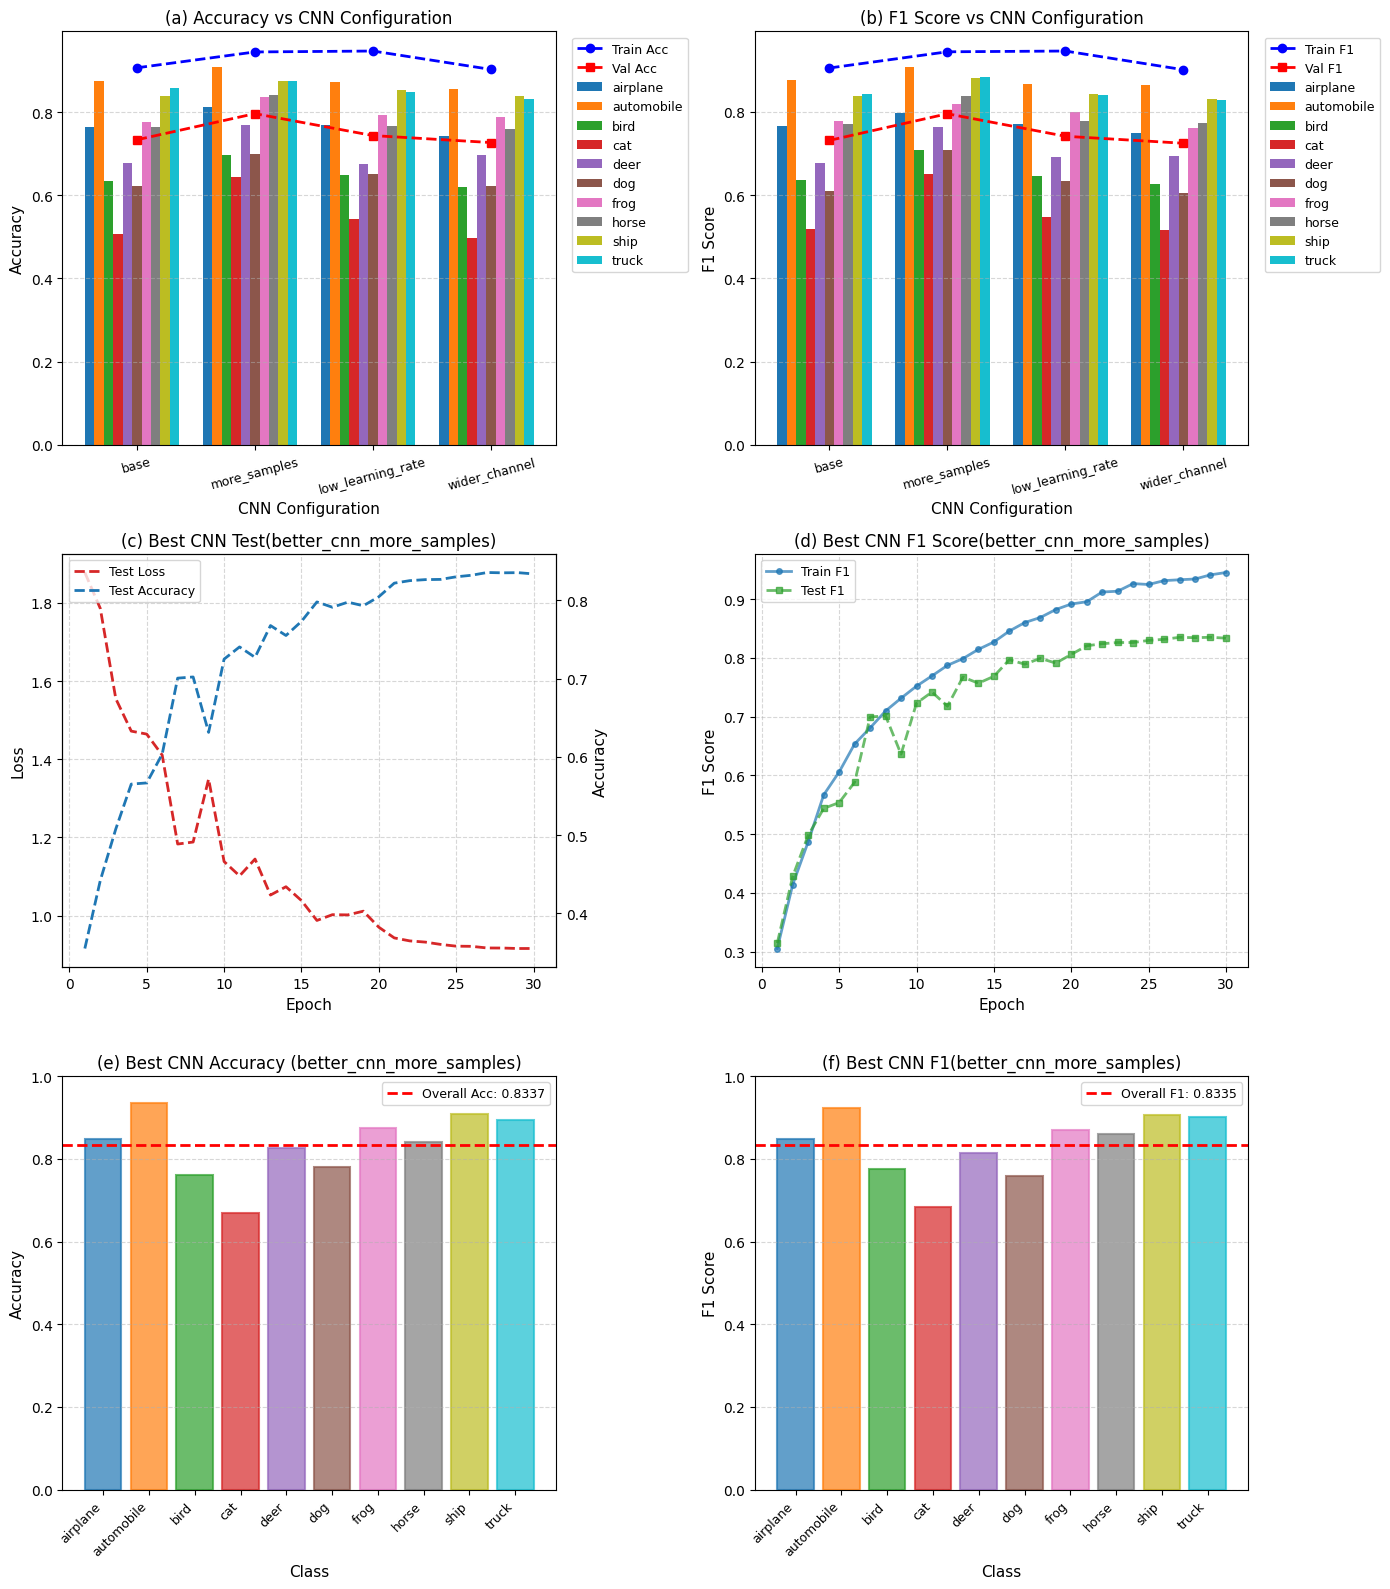

In [44]:
class_colors = plt.cm.tab10(np.arange(len(CIFAR10_CLASSES)))
per_class_rows_cnn = []
for result in cv_detailed_results:
    for i, cname in enumerate(CIFAR10_CLASSES):
        per_class_rows_cnn.append({
            'Config': result['name'],
            'Class': cname,
            'F1': result['per_class_f1'][i],
            'Accuracy': result['per_class_acc'][i]
        })
df_per_class_cnn = pd.DataFrame(per_class_rows_cnn)
plt.figure(figsize=(14, 16))
bar_w = 0.08
plt.subplot(3, 2, 1)
configs_list = [r['name'] for r in cv_detailed_results]
x_cnn = np.arange(len(configs_list))
for idx, cname in enumerate(CIFAR10_CLASSES):
    df_tmp = df_per_class_cnn[df_per_class_cnn["Class"] == cname].copy()
    plt.bar(x_cnn + idx * bar_w, df_tmp["Accuracy"].values, width=bar_w, 
            label=cname, color=class_colors[idx])
train_accs_cnn = [r['train_acc'] for r in cv_detailed_results]
val_accs_cnn = [r['val_acc'] for r in cv_detailed_results]
plt.plot(x_cnn + bar_w * (len(CIFAR10_CLASSES) / 2), train_accs_cnn,
         linestyle="--", linewidth=2, marker='o', color="blue", label="Train Acc")
plt.plot(x_cnn + bar_w * (len(CIFAR10_CLASSES) / 2), val_accs_cnn,
         linestyle="--", linewidth=2, marker='s', color="red", label="Val Acc")
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=9,
    frameon=True
)
plt.xticks(x_cnn + bar_w * (len(CIFAR10_CLASSES) / 2), 
           [name.replace('better_cnn_', '') for name in configs_list], 
           rotation=15, fontsize=9)
plt.xlabel("CNN Configuration", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.title("(a) Accuracy vs CNN Configuration", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplot(3, 2, 2)
for idx, cname in enumerate(CIFAR10_CLASSES):
    df_tmp = df_per_class_cnn[df_per_class_cnn["Class"] == cname].copy()
    plt.bar(x_cnn + idx * bar_w, df_tmp["F1"].values, width=bar_w, 
            label=cname, color=class_colors[idx])
train_f1s_cnn = [r['train_f1'] for r in cv_detailed_results]
val_f1s_cnn = [r['val_f1'] for r in cv_detailed_results]
plt.plot(x_cnn + bar_w * (len(CIFAR10_CLASSES) / 2), train_f1s_cnn,
         linestyle="--", linewidth=2, marker='o', color="blue", label="Train F1")
plt.plot(x_cnn + bar_w * (len(CIFAR10_CLASSES) / 2), val_f1s_cnn,
         linestyle="--", linewidth=2, marker='s', color="red", label="Val F1")
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=9,
    frameon=True
)
plt.xticks(x_cnn + bar_w * (len(CIFAR10_CLASSES) / 2), 
           [name.replace('better_cnn_', '') for name in configs_list], 
           rotation=15, fontsize=9)
plt.xlabel("CNN Configuration", fontsize=11)
plt.ylabel("F1 Score", fontsize=11)
plt.title("(b) F1 Score vs CNN Configuration", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

epochs_range = np.arange(1, len(cnn_train_loss_hist) + 1)
plt.subplot(3, 2, 3)

ax_c = plt.gca()
ax_c.plot(epochs_range, cnn_test_loss_hist, color="tab:red", linestyle='--', linewidth=2, label="Test Loss")
ax_c.set_xlabel("Epoch", fontsize=11)
ax_c.set_ylabel("Loss", fontsize=11)
ax_c.tick_params(axis="y")
ax_c_twin = ax_c.twinx()
ax_c_twin.plot(epochs_range, cnn_test_acc_hist, color="tab:blue", linestyle='--', linewidth=2, label="Test Accuracy")
ax_c_twin.set_ylabel("Accuracy", fontsize=11)
ax_c_twin.tick_params(axis="y")
ax_c.set_title(f"(c) Best CNN Test({best_name})", fontsize=12)
ax_c.grid(True, linestyle="--", alpha=0.5)
lines1, labels1 = ax_c.get_legend_handles_labels()
lines2, labels2 = ax_c_twin.get_legend_handles_labels()
ax_c.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.subplot(3, 2, 4)
plt.plot(epochs_range, cnn_train_f1_hist, linestyle='-', linewidth=2, marker='o', 
         markersize=4, color='tab:blue', alpha=0.7, label='Train F1')
plt.plot(epochs_range, cnn_test_f1_hist, linestyle='--', linewidth=2, marker='s', 
         markersize=4, color='tab:green', alpha=0.7, label='Test F1')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("F1 Score", fontsize=11)
plt.title(f"(d) Best CNN F1 Score({best_name})", fontsize=12)
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(3, 2, 5)
x_classes = np.arange(len(CIFAR10_CLASSES))
bars = plt.bar(x_classes, best_cnn_results['per_class_acc'], 
               alpha=0.7, edgecolor='black', linewidth=1.5)
for idx, bar in enumerate(bars):
    bar.set_color(class_colors[idx])
overall_acc = np.mean(best_cnn_results['per_class_acc'])
plt.axhline(y=overall_acc, color='red', linestyle='--', linewidth=2, 
           label=f'Overall Acc: {overall_acc:.4f}')
plt.xticks(x_classes, CIFAR10_CLASSES, rotation=45, ha='right', fontsize=9)
plt.xlabel("Class", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.title(f"(e) Best CNN Accuracy ({best_name})", fontsize=12)
plt.legend(fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim([0, 1])

plt.subplot(3, 2, 6)
bars = plt.bar(x_classes, best_cnn_results['per_class_f1'], 
               alpha=0.7, edgecolor='black', linewidth=1.5)
for idx, bar in enumerate(bars):
    bar.set_color(class_colors[idx])
overall_f1 = np.mean(best_cnn_results['per_class_f1'])
plt.axhline(y=overall_f1, color='red', linestyle='--', linewidth=2, 
           label=f'Overall F1: {overall_f1:.4f}')
plt.xticks(x_classes, CIFAR10_CLASSES, rotation=45, ha='right', fontsize=9)
plt.xlabel("Class", fontsize=11)
plt.ylabel("F1 Score", fontsize=11)
plt.title(f"(f) Best CNN F1({best_name})", fontsize=12)
plt.legend(fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "task3.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### Task 4

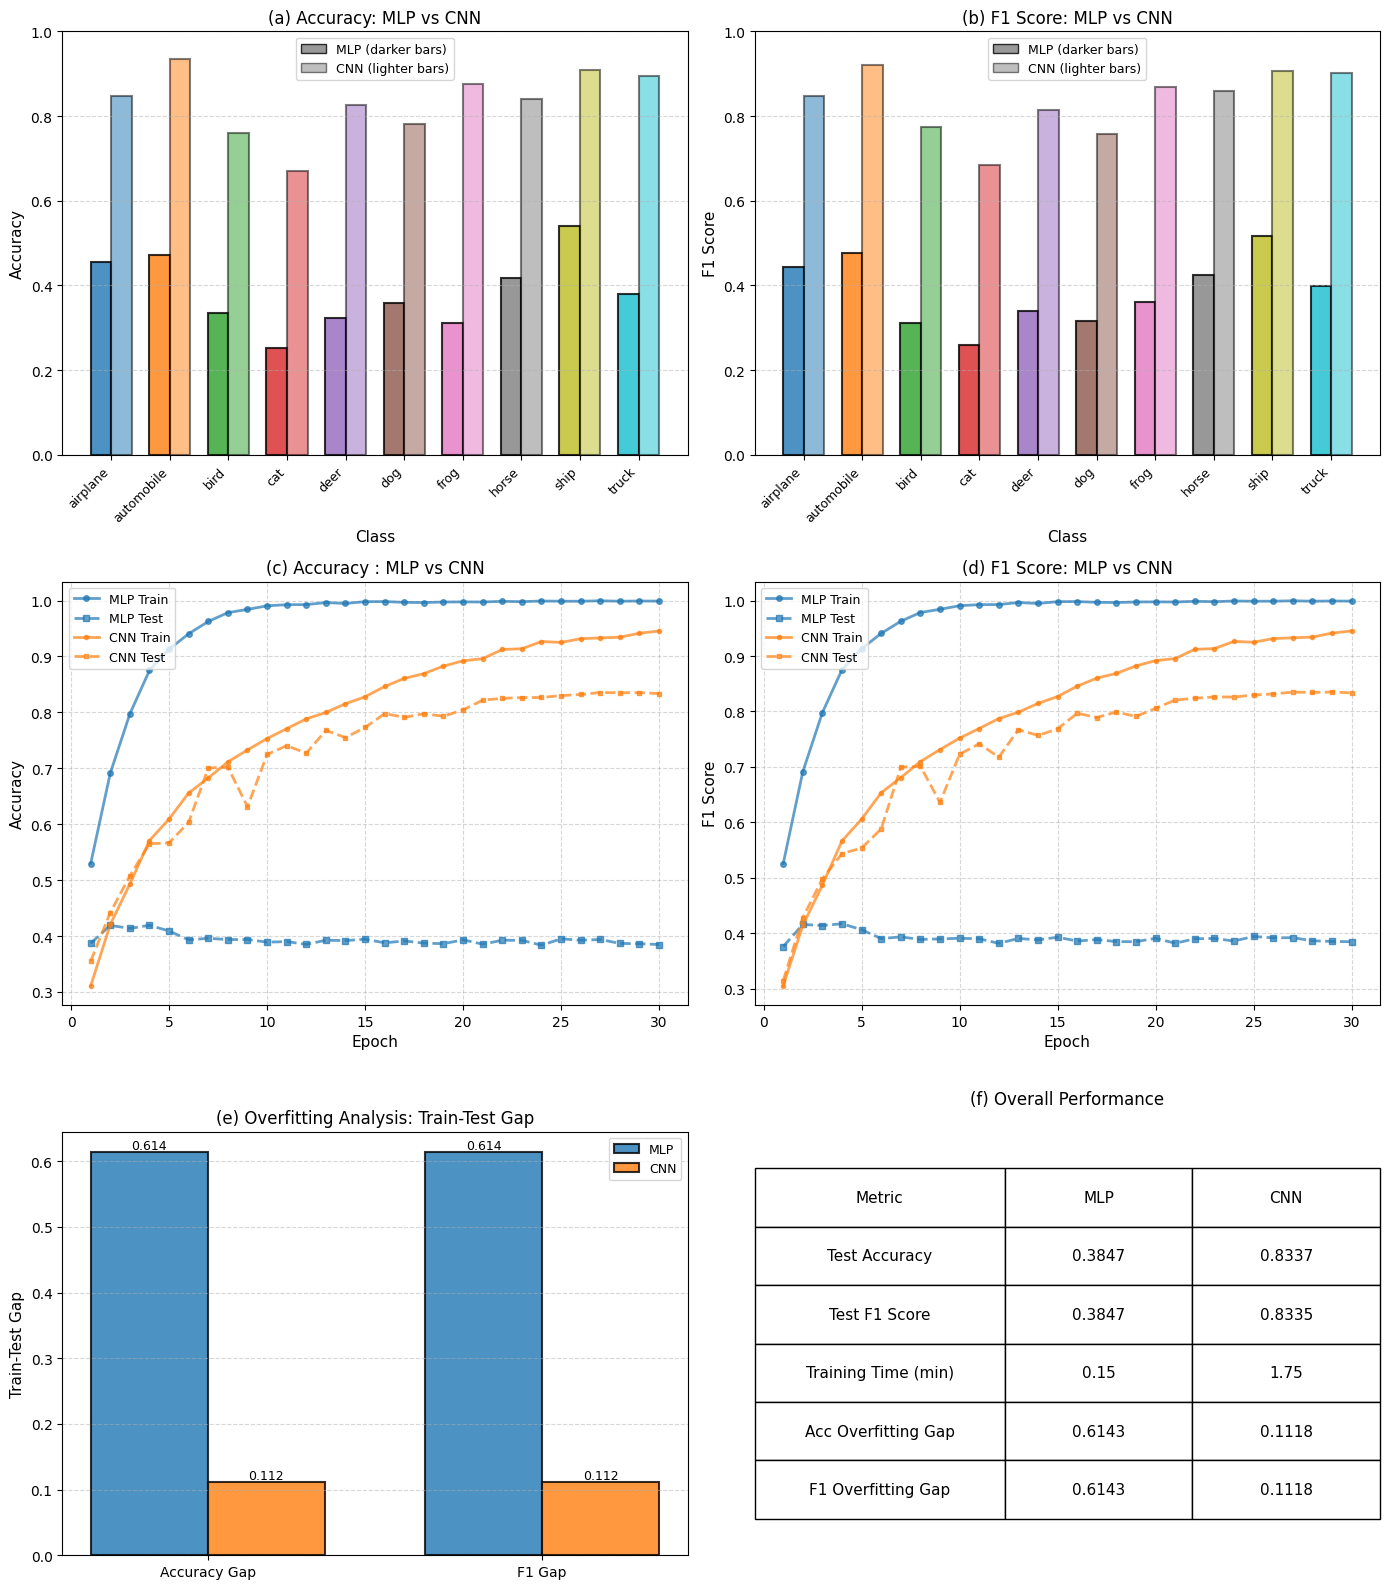

In [ ]:
df_final_24 = pd.DataFrame(final_results)
best_mlp_idx = df_final_24['test_acc'].idxmax()
best_mlp_curve = learning_curves[best_mlp_idx]
best_mlp_result = final_results[best_mlp_idx]
best_mlp_name = best_mlp_result['name']
mlp_per_class_data = df_per_class_24[df_per_class_24['Config'] == best_mlp_name].copy()
mlp_per_class_acc = mlp_per_class_data['Accuracy'].values
mlp_per_class_f1 = mlp_per_class_data['F1'].values
class_colors = plt.cm.tab10(np.arange(len(CIFAR10_CLASSES)))
model_colors = {'MLP': 'tab:blue', 'CNN': 'tab:orange'}
mlp_training_time = df_cv_plot.loc[
    df_cv_plot["Feature"] == "PCA100%",
    "Time_min"
].values[0] 
cnn_training_time = df_results.loc[best_idx, 'Time_min']  

fig = plt.figure(figsize=(14, 16))
plt.subplot(3, 2, 1)
x_classes = np.arange(len(CIFAR10_CLASSES))
width = 0.35
for idx in range(len(CIFAR10_CLASSES)):
    plt.bar(x_classes[idx] - width/2, mlp_per_class_acc[idx], width, 
            color=class_colors[idx], alpha=0.8, edgecolor='black', linewidth=1.5)
    plt.bar(x_classes[idx] + width/2, best_cnn_results['per_class_acc'][idx], width, 
            color=class_colors[idx], alpha=0.5, edgecolor='black', linewidth=1.5)
from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor='gray',
        alpha=0.8,
        edgecolor='black',
        label='MLP (darker bars)'
    ),
    Patch(
        facecolor='gray',
        alpha=0.5,
        edgecolor='black',
        label='CNN (lighter bars)'
    )
]

plt.legend(handles=legend_elements, fontsize=9, loc='best')
plt.xticks(x_classes, CIFAR10_CLASSES, rotation=45, ha='right', fontsize=9)
plt.xlabel("Class", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.title("(a) Accuracy: MLP vs CNN", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim([0, 1])

plt.subplot(3, 2, 2)
for idx in range(len(CIFAR10_CLASSES)):
    plt.bar(x_classes[idx] - width/2, mlp_per_class_f1[idx], width, 
            color=class_colors[idx], alpha=0.8, edgecolor='black', linewidth=1.5)
    plt.bar(x_classes[idx] + width/2, best_cnn_results['per_class_f1'][idx], width, 
            color=class_colors[idx], alpha=0.5, edgecolor='black', linewidth=1.5)
plt.legend(handles=legend_elements, fontsize=9, loc='best')
plt.xticks(x_classes, CIFAR10_CLASSES, rotation=45, ha='right', fontsize=9)
plt.xlabel("Class", fontsize=11)
plt.ylabel("F1 Score", fontsize=11)
plt.title("(b) F1 Score: MLP vs CNN", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim([0, 1])
mlp_epochs = np.arange(1, len(best_mlp_curve['train_acc']) + 1)
cnn_epochs = np.arange(1, len(cnn_train_acc_hist) + 1)

plt.subplot(3, 2, 3)
plt.plot(mlp_epochs, best_mlp_curve['train_acc'], linestyle='-', linewidth=2, 
         marker='o', markersize=4, color=model_colors['MLP'], alpha=0.7, label='MLP Train')
plt.plot(mlp_epochs, best_mlp_curve['test_acc'], linestyle='--', linewidth=2, 
         marker='s', markersize=4, color=model_colors['MLP'], alpha=0.7, label='MLP Test')
plt.plot(cnn_epochs, cnn_train_acc_hist, linestyle='-', linewidth=2, 
         marker='o', markersize=3, color=model_colors['CNN'], alpha=0.7, label='CNN Train')
plt.plot(cnn_epochs, cnn_test_acc_hist, linestyle='--', linewidth=2, 
         marker='s', markersize=3, color=model_colors['CNN'], alpha=0.7, label='CNN Test')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.title("(c) Accuracy : MLP vs CNN", fontsize=12)
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(3, 2, 4)
plt.plot(mlp_epochs, best_mlp_curve['train_f1'], linestyle='-', linewidth=2, 
         marker='o', markersize=4, color=model_colors['MLP'], alpha=0.7, label='MLP Train')
plt.plot(mlp_epochs, best_mlp_curve['test_f1'], linestyle='--', linewidth=2, 
         marker='s', markersize=4, color=model_colors['MLP'], alpha=0.7, label='MLP Test')
plt.plot(cnn_epochs, cnn_train_f1_hist, linestyle='-', linewidth=2, 
         marker='o', markersize=3, color=model_colors['CNN'], alpha=0.7, label='CNN Train')
plt.plot(cnn_epochs, cnn_test_f1_hist, linestyle='--', linewidth=2, 
         marker='s', markersize=3, color=model_colors['CNN'], alpha=0.7, label='CNN Test')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("F1 Score", fontsize=11)
plt.title("(d) F1 Score: MLP vs CNN", fontsize=12)
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)

mlp_acc_gap = best_mlp_result['train_acc'] - best_mlp_result['test_acc']
mlp_f1_gap = best_mlp_result['train_f1'] - best_mlp_result['test_f1']
cnn_acc_gap = cnn_train_acc_hist[-1] - cnn_test_acc_hist[-1]
cnn_f1_gap = cnn_train_f1_hist[-1] - cnn_test_f1_hist[-1]

plt.subplot(3, 2, 5)
metrics = ['Accuracy Gap', 'F1 Gap']
x_pos = np.arange(len(metrics))
width = 0.35
mlp_gaps = [mlp_acc_gap, mlp_f1_gap]
cnn_gaps = [cnn_acc_gap, cnn_f1_gap]
bars1 = plt.bar(x_pos - width/2, mlp_gaps, width, label='MLP', 
               alpha=0.8, color=model_colors['MLP'], edgecolor='black', linewidth=1.5)
bars2 = plt.bar(x_pos + width/2, cnn_gaps, width, label='CNN', 
               alpha=0.8, color=model_colors['CNN'], edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.xticks(x_pos, metrics, fontsize=10)
plt.ylabel("Train-Test Gap", fontsize=11)
plt.title("(e) Overfitting Analysis: Train-Test Gap", fontsize=12)
plt.legend(fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

ax6 = plt.subplot(3, 2, 6)
ax6.axis('tight')
ax6.axis('off')
table_data = [
    ['Test Accuracy', f'{best_mlp_result["test_acc"]:.4f}', f'{cnn_test_acc_hist[-1]:.4f}'],
    ['Test F1 Score', f'{best_mlp_result["test_f1"]:.4f}', f'{cnn_test_f1_hist[-1]:.4f}'],
    ['Training Time (min)', f'{mlp_training_time:.2f}', f'{cnn_training_time:.2f}'],
    ['Acc Overfitting Gap', f'{mlp_acc_gap:.4f}', f'{cnn_acc_gap:.4f}'],
    ['F1 Overfitting Gap', f'{mlp_f1_gap:.4f}', f'{cnn_f1_gap:.4f}'],
]

table = ax6.table(cellText=table_data,
                  colLabels=['Metric', 'MLP', 'CNN'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.4, 0.3, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

ax6.set_title("(f) Overall Performance", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "task4_mlp_vs_cnn.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()